# Day 1: Convolution from Scratch

**COMP 395 — Deep Learning**

In this in-class assignment, you will:
1. Load a grayscale image as a PyTorch tensor
2. Implement 2D convolution from scratch, first with four loops, then with two
3. Apply edge-detection kernels to a real image
4. Compare your implementation to PyTorch's built-in convolution

**Paired work.** One person drives, one navigates. Switch roles at Part 3.

---

## Part 0: Setup

Create a folder for today's assignment and put **both** files in it:
- this notebook (`day1_convolution.ipynb`)
- `cameraman.png`

Then open the notebook from that folder. The image is loaded by file name, so it must sit right next to the notebook.

In [23]:
import os
import time
import torch
import torch.nn.functional as F
from torchvision.io import read_image, ImageReadMode
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

## Part 1: Images as Tensors

### 1.1 Loading a grayscale image

The classic "cameraman" test image has clear edges (person, tripod, buildings) that make convolution results easy to interpret.

**🧑‍🏫 Code along:** we'll type this cell together in class. The code is on the slide. Three steps:

1. **Read** `cameraman.png` as grayscale with `read_image`. This gives a tensor of shape `(1, H, W)`: one channel, because we asked for grayscale.
2. **Drop** that channel dimension with `.squeeze(0)` and convert the integer pixel values to floats with `.float()`.
3. **Downsample** to 256×256 by keeping every other row and column (`[::2, ::2]`). Our from-scratch convolution uses Python loops, and a quarter as many pixels means a quarter of the wait.

Shape: torch.Size([256, 256])   (should be torch.Size([256, 256]))
Data type: torch.float32
Value range: [1.0, 255.0]


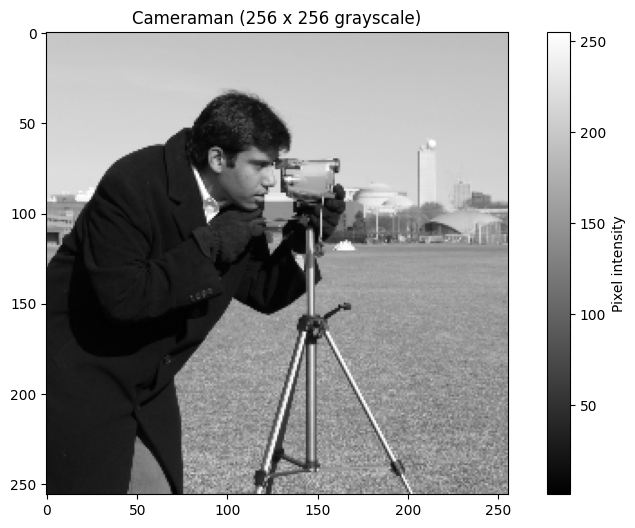

In [24]:
assert os.path.exists("cameraman.png"), (
    "cameraman.png not found. Put it in the same folder as this notebook, "
    "then restart the kernel and run from the top."
)

# Read one grayscale channel, convert to float, and downsample to 256 x 256.
img = read_image("cameraman.png", mode=ImageReadMode.GRAY)
img = img.squeeze(0).float()
img = img[::2, ::2]

assert img.shape == (256, 256)
assert img.dtype == torch.float32

print(f"Shape: {img.shape}   (should be torch.Size([256, 256]))")
print(f"Data type: {img.dtype}")
print(f"Value range: [{img.min().item()}, {img.max().item()}]")

plt.imshow(img)
plt.title(f"Cameraman ({img.shape[0]} x {img.shape[1]} grayscale)")
plt.colorbar(label="Pixel intensity")
plt.show()

### 1.2 Zooming in: what the numbers look like

Here is an 8×8 patch where the back of the cameraman's head meets the sky — a sharp boundary between dark and bright pixels.

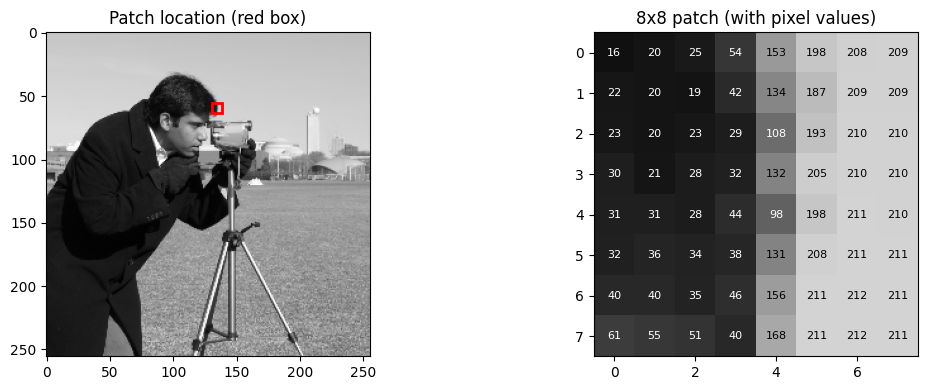

In [25]:
# 8x8 patch on the edge between the dark head (left) and the bright sky (right)
patch = img[56:64, 131:139]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Where is this patch in the full image?
axes[0].imshow(img)
axes[0].add_patch(plt.Rectangle((131 - 0.5, 56 - 0.5), 8, 8,
                                edgecolor='red', facecolor='none', linewidth=2))
axes[0].set_title("Patch location (red box)")

# The patch itself, with pixel values
axes[1].imshow(patch, vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        v = int(patch[i, j])
        axes[1].text(j, i, str(v), ha='center', va='center', fontsize=8,
                     color='white' if v < 128 else 'black')
axes[1].set_title("8x8 patch (with pixel values)")

plt.tight_layout()
plt.show()

**Quick check:** Reading across any row of the patch, where do the values jump? That jump *is* the edge. Convolution is a systematic way to find jumps like this everywhere in the image.

## Part 2: The Formula and a Test Case

From the slides, for a $k \times k$ kernel $K$:

$$\text{Output}(i, j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I(i+m, j+n) \cdot K(m, n)$$

The output has shape $(H - k + 1, W - k + 1)$, because the kernel can't extend past the image boundary.

Below is a tiny image with a known answer that we'll use to test your code. At position $(1, 1)$, the patch is two rows of 10s above a row of 200s, so the horizontal edge kernel gives $(200 + 200 + 200) - (10 + 10 + 10) = 570$.

In [26]:
# A tiny 5x5 "image": dark on top, bright on bottom
tiny_image = torch.tensor([
    [ 10,  10,  10,  10,  10],
    [ 10,  10,  10,  10,  10],
    [ 10,  10,  10,  10,  10],
    [200, 200, 200, 200, 200],
    [200, 200, 200, 200, 200],
], dtype=torch.float32)

# Horizontal edge kernel: (bottom row) - (top row)
h_edge_kernel = torch.tensor([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=torch.float32)

patch = tiny_image[1:4, 1:4]
print("Patch at (1, 1):")
print(patch.int())
print(f"\nOutput at (1, 1): {torch.sum(patch * h_edge_kernel).item()}")

Patch at (1, 1):
tensor([[ 10,  10,  10],
        [ 10,  10,  10],
        [200, 200, 200]], dtype=torch.int32)

Output at (1, 1): 570.0


## Part 3: Implement Convolution from Scratch

**🔄 Switch driver/navigator here.**

### 3.1 Your task: the four-loop version

Complete `convolve2d_loops` so it matches the formula exactly:
1. Compute the output dimensions
2. **Outer two loops** (`i`, `j`): slide the kernel to every valid position
3. **Inner two loops** (`m`, `n`): multiply each kernel weight by the pixel under it and add it to a running total
4. Store the total in `output[i, j]`

**Do not use `F.conv2d`, `nn.Conv2d`, or any other library convolution.** The point is to see exactly what's happening.

| Formula | Code |
|---|---|
| $\text{Output}(i, j)$ | `output[i, j]` |
| $\sum_m \sum_n$ | `for m in range(k): for n in range(k):` |
| $I(i+m,\ j+n)$ | `image[i + m, j + n]` |
| $K(m, n)$ | `kernel[m, n]` |

In [27]:
def convolve2d_loops(image, kernel):
    """
    Apply a 2D convolution of `kernel` over `image` using four nested loops.

    Parameters
    ----------
    image : torch.Tensor, shape (H, W)
        Grayscale image as a 2D tensor.
    kernel : torch.Tensor, shape (k, k)
        Square convolution kernel.

    Returns
    -------
    output : torch.Tensor, shape (H - k + 1, W - k + 1)
        The convolution result.
    """
    H, W = image.shape
    k = kernel.shape[0]  # kernel is k x k

    # Valid convolution: the kernel must stay inside the image.
    out_h = H - k + 1
    out_w = W - k + 1

    output = image.new_zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            total = 0.0
            for m in range(k):
                for n in range(k):
                    total += image[i + m, j + n] * kernel[m, n]

            output[i, j] = total

    return output

### 3.2 Test on the tiny image

In [28]:
tiny_output = convolve2d_loops(tiny_image, h_edge_kernel)
print("Tiny image convolution output:")
print(tiny_output.int())
print()
print("Position (1,1) should be 570")
print(f"Your result at (1,1): {tiny_output[1, 1].item()}")

expected = torch.tensor([[0., 0., 0.], [570., 570., 570.], [570., 570., 570.]])
torch.testing.assert_close(tiny_output, expected)

Tiny image convolution output:
tensor([[  0,   0,   0],
        [570, 570, 570],
        [570, 570, 570]], dtype=torch.int32)

Position (1,1) should be 570
Your result at (1,1): 570.0


### 3.3 From four loops to two: let PyTorch do the inner loops

Look at what your two inner loops do: they take the $k \times k$ patch `image[i:i+k, j:j+k]`, multiply it element-wise by `kernel`, and add everything up. PyTorch can do that in one line:

```python
torch.sum(image[i:i+k, j:j+k] * kernel)
```

Same math, two fewer Python loops. The diagram shows what changes, using the tiny image with the kernel at position $(1, 1)$.

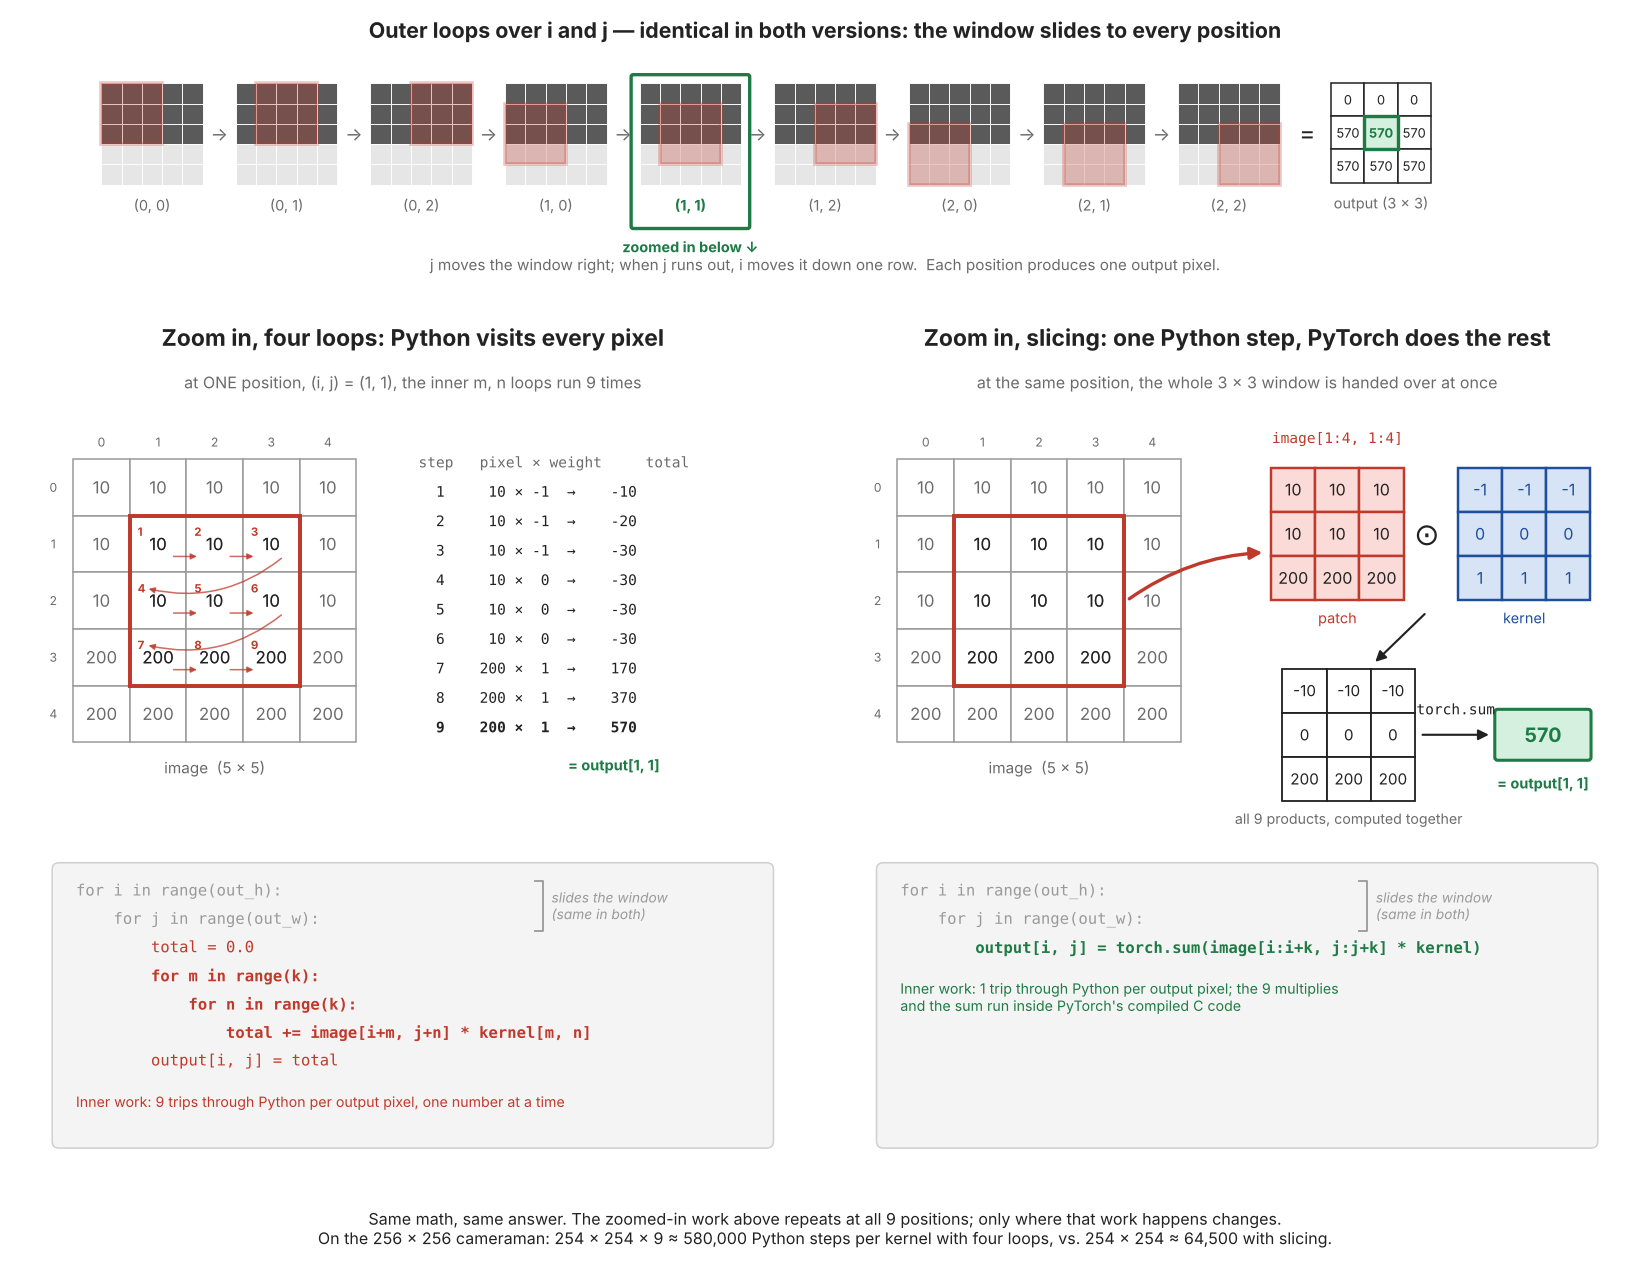

**What the diagram shows.**

**Top strip — the outer loops.** In *both* versions, the loops over `i` and `j` slide the window across the whole image: right along a row, then down to the next row, until every position has been visited. Each stop produces one output pixel, filling the 3×3 output grid. This part doesn't change at all.

**Bottom panels — zoom in on one stop.** What *does* change is the work done at each stop. The panels zoom in on position $(1, 1)$, but the same thing happens at all 9 positions:

- **Four loops (left):** Python handles the 9 pixels one at a time. For each one it indexes the image, indexes the kernel, multiplies, and adds to `total`: 9 separate trips through the Python interpreter, building up the running total shown in the table.
- **Slicing (right):** Python makes **one** call. `image[i:i+k, j:j+k]` hands PyTorch the whole 3×3 block, and the 9 multiplies and the sum all happen inside PyTorch's compiled C code.

Every trip through Python has overhead (looking up variables, making a small tensor for each indexed value), so fewer trips means faster code. Moving work out of Python loops and into whole-tensor operations is called **vectorization**, and it is one of the most important ideas in deep learning code. `F.conv2d`, which you'll time in Part 5, goes one step further: it hands over *every* window position at once, so even the outer loops disappear.

**Your task:** complete `convolve2d` below using only the two outer loops and the one-liner. We'll use this version on the real image for the rest of the assignment.

In [29]:
def convolve2d(image, kernel):
    """Same as convolve2d_loops, but the inner two loops are replaced by slicing."""
    H, W = image.shape
    k = kernel.shape[0]
    out_h = H - k + 1
    out_w = W - k + 1
    output = image.new_zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = torch.sum(image[i:i + k, j:j + k] * kernel)

    return output

In [30]:
# Check: both versions must agree. Use a small crop so the four-loop version is quick.
crop = img[:32, :32]
fast = convolve2d(crop, h_edge_kernel)
slow = convolve2d_loops(crop, h_edge_kernel)

print(f"Input shape:  {tuple(crop.shape)}")
print(f"Output shape: {tuple(fast.shape)}   (should be one pixel smaller on every side)")
print(f"Max difference between the two versions: {torch.max(torch.abs(fast - slow)).item()}   (should be 0.0)")

assert fast.shape == (30, 30)
torch.testing.assert_close(fast, slow)

Input shape:  (32, 32)
Output shape: (30, 30)   (should be one pixel smaller on every side)
Max difference between the two versions: 0.0   (should be 0.0)


## Part 4: Edge Detection on a Real Image

Now let's apply the Sobel kernels from class to the cameraman image.

| Sobel-X | Sobel-Y |
|---|---|
| `[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]` | `[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]` |
| right minus left → **vertical** edges | bottom minus top → **horizontal** edges |

### ✏️ Prediction (write your answer before running the code)

Look at the cameraman image above:
- **Sobel-X (vertical edges):** which parts of the image do you expect will "light up"?
- **Sobel-Y (horizontal edges):** which parts?

*Your prediction:*

(Write here)
- Sobel-X (vertical edges): I expect the tripod legs, the vertical parts of the cameraman's outline (the left side of his coat and his back), and the tall buildings in the background to light up, because along these lines brightness changes from left to right.
- Sobel-Y (horizontal edges): I expect the horizon (where the grass meets the buildings), the top and bottom edges of the camera, and his head and shoulders to light up, because along these lines brightness changes from top to bottom. Diagonal edges, like the slanted tripod legs, should show up weakly in both.
---

**How to read the output plots:** the raw convolution output is *signed*. A dark-to-bright edge gives a large positive number and a bright-to-dark edge gives a large negative number. So that both kinds of edge show up as bright, we plot the **absolute value**.

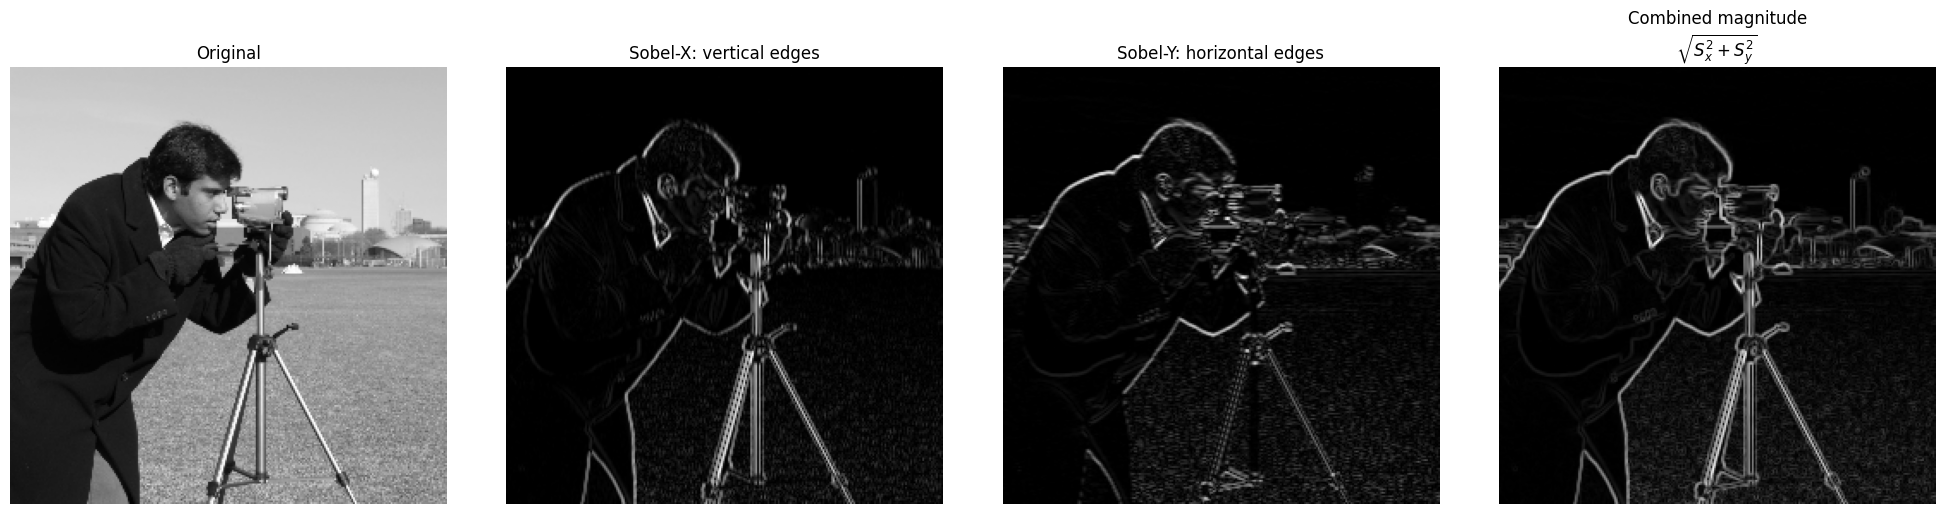

In [31]:
sobel_x_kernel = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=torch.float32)

sobel_y_kernel = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
], dtype=torch.float32)

sobel_x = convolve2d(img, sobel_x_kernel)
sobel_y = convolve2d(img, sobel_y_kernel)
edge_magnitude = torch.sqrt(sobel_x**2 + sobel_y**2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
panels = [
    (img, "Original"),
    (sobel_x.abs(), "Sobel-X: vertical edges"),
    (sobel_y.abs(), "Sobel-Y: horizontal edges"),
    (edge_magnitude, "Combined magnitude\n" + r"$\sqrt{S_x^2 + S_y^2}$"),
]
for ax, (image, title) in zip(axes, panels):
    ax.imshow(image)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

### ✏️ Think–Pair–Share

1. **Check your predictions:** Did each Sobel kernel highlight what you expected? What surprised you?

2. **Combined magnitude:** The last panel computes $\sqrt{S_x^2 + S_y^2}$. Why does combining both directions give us the "full" edges? (Hint: think back to gradient vectors in Assignment 1.)

3. **Connection to CNNs:** In a CNN, the kernel values are *learned* by backpropagation. What would it mean for a network to "learn" a Sobel-like filter in its first layer?

---

## Part 5: Same Operation, Different Weights

### 5.1 Other kernels

Convolution isn't only for edges. Nothing about the operation changes below, only the nine weights. Run the cell and look at the effects:

- **Blur:** every weight is 1/9, so each output pixel is the average of its 3×3 neighborhood.
- **Sharpen:** a large center weight minus the four neighbors exaggerates differences between a pixel and its surroundings.

In a CNN, the network chooses these weights for itself.

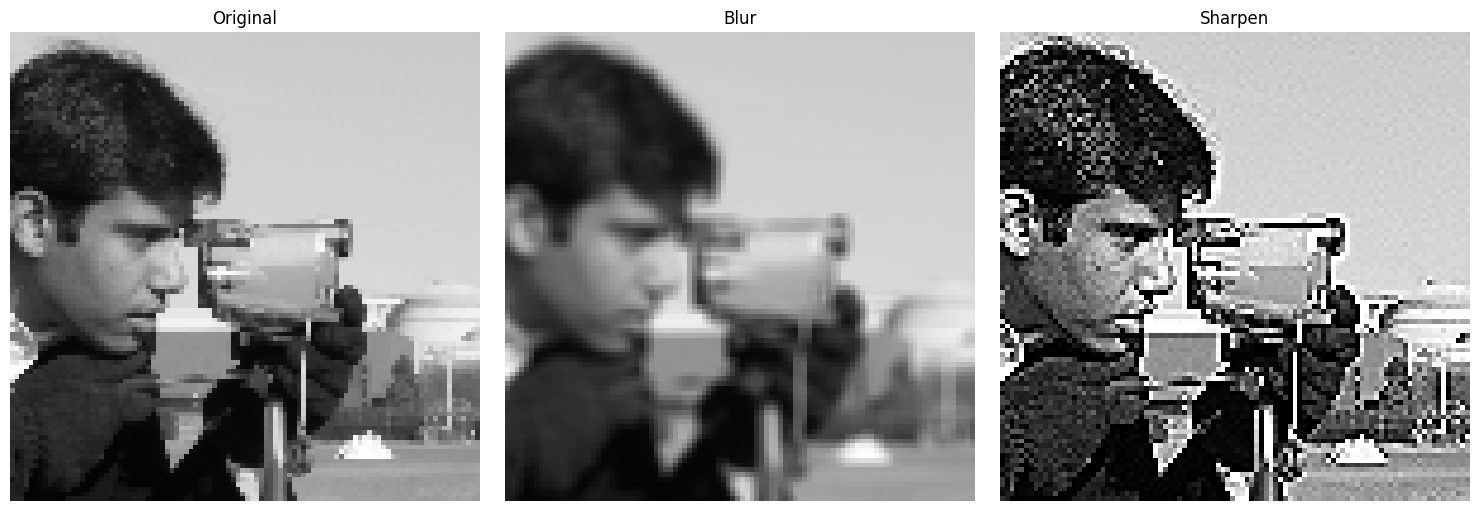

In [32]:
blur_kernel = torch.ones(3, 3) / 9.0

sharpen_kernel = torch.tensor([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0],
], dtype=torch.float32)

# Zoom in on the head and camera so the effects are easy to see
region = img[30:130, 90:190]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (image, title) in zip(axes, [
    (region, "Original"),
    (convolve2d(region, blur_kernel), "Blur"),
    (convolve2d(region, sharpen_kernel), "Sharpen"),
]):
    ax.imshow(image, vmin=0, vmax=255)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 5.2 How fast is the real thing?

PyTorch has convolution built in as `F.conv2d`. It expects 4D tensors of shape `(batch, channels, height, width)`, so we add two size-1 dimensions with `unsqueeze`. Run the cell and compare.

One thing to notice: `F.conv2d` gives exactly your answer *without* flipping the kernel. Strictly speaking, the operation we've implemented is called **cross-correlation** (mathematical convolution flips the kernel first), but deep learning libraries use the unflipped version and call it convolution anyway.

In [33]:
start = time.perf_counter()
ours = convolve2d(img, sobel_x_kernel)
ours_time = time.perf_counter() - start

start = time.perf_counter()
theirs = F.conv2d(img.unsqueeze(0).unsqueeze(0),              # (1, 1, 256, 256)
                  sobel_x_kernel.unsqueeze(0).unsqueeze(0))   # (1, 1, 3, 3)
theirs = theirs.squeeze()                                     # back to (254, 254)
theirs_time = time.perf_counter() - start

print(f"Our convolve2d: {ours_time:.3f} s")
print(f"F.conv2d:       {theirs_time:.5f} s")
print(f"Speedup:        ~{ours_time / theirs_time:,.0f}x")
print(f"Same result?    {torch.allclose(ours, theirs)}")

assert ours.shape == (254, 254)
torch.testing.assert_close(ours, theirs)

Our convolve2d: 0.535 s
F.conv2d:       0.08026 s
Speedup:        ~7x
Same result?    True


## Part 6: Exit Ticket

### ✏️ Answer these in your own words (graded for completeness, not correctness):

**1.** In one or two sentences, what does the convolution operation do to an image?

*Your answer:*

**2.** `convolve2d_loops` has four nested loops. In Big-O notation, what is its time complexity in terms of image dimensions ($H$, $W$) and kernel size ($k$)? Given the speedup you saw in 5.2, why does this matter for real CNN training?

*Your answer:*

**3.** What is one thing that clicked for you today, and one thing you're still unsure about?

*Your answer:*

---

**Next class:** We'll extend convolution to color (RGB) images, introduce pooling, and use PyTorch's `nn.Conv2d` — the same `F.conv2d` you just timed, but with *learnable* kernels. This sets us up to build a full CNN for MNIST digit classification.